# Exploratory Data Analysis

This notebook explores the cleaned Olist-style dataset to understand customer behavior, order performance, product mix, and seller-level patterns.

In [5]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np

try:
    import matplotlib.pyplot as plt
    import seaborn as sns
except ModuleNotFoundError:
    import subprocess

    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib", "seaborn"])
    import matplotlib.pyplot as plt
    import seaborn as sns


def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "raw data").exists():
            return candidate
    return start


notebook_dir = Path.cwd().resolve()
project_root = find_project_root(notebook_dir)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data_cleaning import ROOT_DIR

DATA_DIR = ROOT_DIR / "data" / "cleaned"
expected_files = [
    "customers_cleaned.csv",
    "geolocation_cleaned.csv",
    "order_items_cleaned.csv",
    "order_payments_cleaned.csv",
    "reviews_cleaned.csv",
    "orders_cleaned.csv",
    "products_cleaned.csv",
    "sellers_cleaned.csv",
]

missing_files = [name for name in expected_files if not (DATA_DIR / name).exists()]
if missing_files:
    raise FileNotFoundError(f"Missing cleaned files: {missing_files}")

customers = pd.read_csv(DATA_DIR / "customers_cleaned.csv")
geolocation = pd.read_csv(DATA_DIR / "geolocation_cleaned.csv")
order_items = pd.read_csv(DATA_DIR / "order_items_cleaned.csv")
order_payments = pd.read_csv(DATA_DIR / "order_payments_cleaned.csv")
reviews = pd.read_csv(DATA_DIR / "reviews_cleaned.csv")
orders = pd.read_csv(DATA_DIR / "orders_cleaned.csv")
products = pd.read_csv(DATA_DIR / "products_cleaned.csv")
sellers = pd.read_csv(DATA_DIR / "sellers_cleaned.csv")

print("Loaded datasets:")
for name in ["customers", "orders", "order_items", "order_payments", "reviews", "products", "sellers"]:
    df = locals()[name]
    print(f"- {name}: {df.shape[0]} rows, {df.shape[1]} columns")


Matplotlib is building the font cache; this may take a moment.


Loaded datasets:
- customers: 99441 rows, 5 columns
- orders: 99441 rows, 10 columns
- order_items: 112650 rows, 7 columns
- order_payments: 103886 rows, 5 columns
- reviews: 99224 rows, 7 columns
- products: 32951 rows, 10 columns
- sellers: 3095 rows, 4 columns


In [6]:
# Basic data quality summary
for name in ["customers", "orders", "order_items", "order_payments", "reviews", "products", "sellers"]:
    df = locals()[name]
    print(f"\n{name} missing values:")
    print(df.isna().sum().sort_values(ascending=False).head(10))


customers missing values:
customer_id           0
customer_unique_id    0
zip_code_prefix       0
city                  0
state                 0
dtype: int64

orders missing values:
order_delivered_customer_date    2965
delivery_delay_days              2965
order_delivered_carrier_date     1783
order_approved_at                 160
customer_id                         0
order_id                            0
order_status                        0
order_purchase_timestamp            0
order_estimated_delivery_date       0
is_delivered                        0
dtype: int64

order_items missing values:
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

order_payments missing values:
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

reviews missing values:
review

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


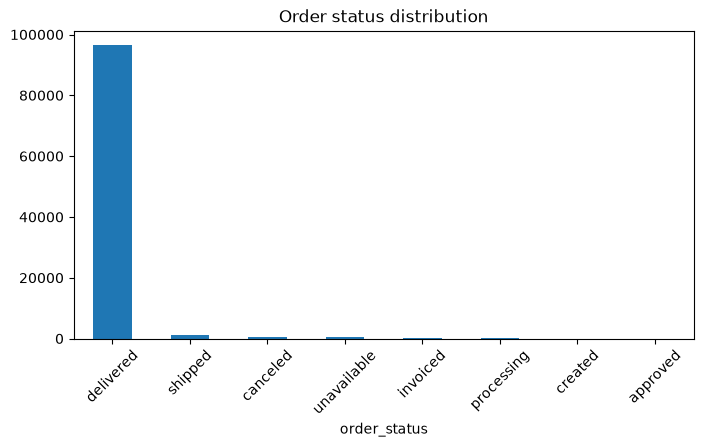

In [7]:
# Order status distribution
order_status_counts = orders["order_status"].value_counts(dropna=False)
print(order_status_counts)
order_status_counts.plot(kind="bar", figsize=(8, 4), title="Order status distribution")
plt.xticks(rotation=45)
plt.show()

payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


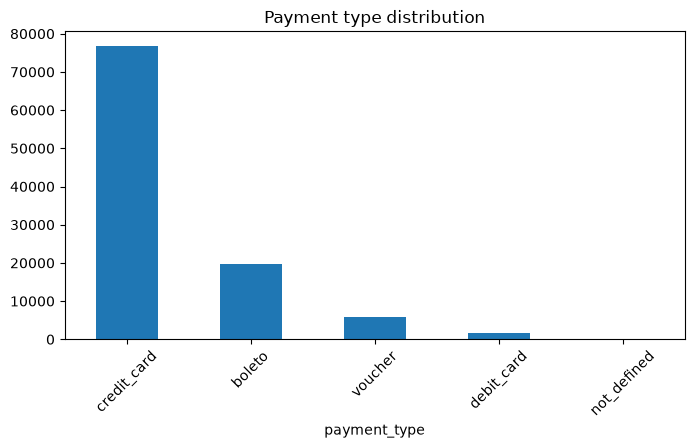

In [10]:
# Payment method mix
payment_mix = order_payments["payment_type"].value_counts()
print(payment_mix)
payment_mix.plot(kind="bar", figsize=(8, 4), title="Payment type distribution")
plt.xticks(rotation=45)
plt.show()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


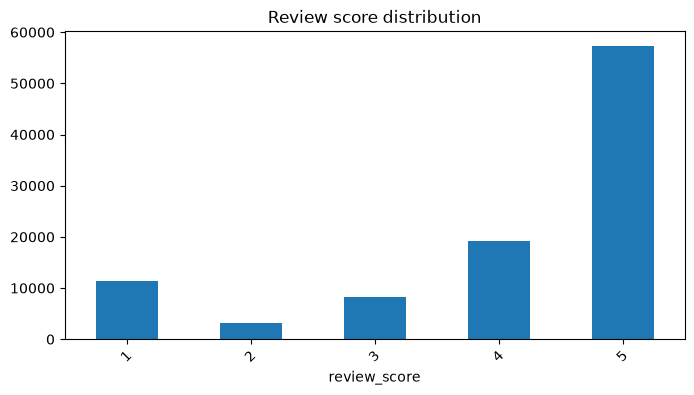

In [9]:
# Review score distribution
review_score_counts = reviews["review_score"].value_counts().sort_index()
print(review_score_counts)
review_score_counts.plot(kind="bar", figsize=(8, 4), title="Review score distribution")
plt.xticks(rotation=45)
plt.show()

In [14]:
# Merge order-level information for richer analysis
orders_enriched = orders.merge(customers[["customer_id", "city", "state"]], on="customer_id", how="left")
orders_enriched = orders_enriched.merge(order_items, on="order_id", how="left")
orders_enriched = orders_enriched.merge(order_payments, on="order_id", how="left")
orders_enriched = orders_enriched.merge(products[["product_id", "product_category_name_english", "product_weight_g"]], on="product_id", how="left")
orders_enriched = orders_enriched.merge(sellers[["seller_id", "seller_city", "seller_state"]], on="seller_id", how="left")
orders_enriched = orders_enriched.merge(reviews[["order_id", "review_score"]].drop_duplicates(subset=["order_id"]), on="order_id", how="left")

orders_enriched.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_delivered,delivery_delay_days,...,freight_value,payment_sequential,payment_type,payment_installments,payment_value,product_category_name_english,product_weight_g,seller_city,seller_state,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,-8.0,...,8.72,1.0,credit_card,1.0,18.12,housewares,500.0,maua,SP,4.0
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,-8.0,...,8.72,3.0,voucher,1.0,2.00,housewares,500.0,maua,SP,4.0
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,True,-8.0,...,8.72,2.0,voucher,1.0,18.59,housewares,500.0,maua,SP,4.0
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,True,-6.0,...,22.76,1.0,boleto,1.0,141.46,perfumery,400.0,belo horizonte,SP,4.0
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,True,-18.0,...,19.22,1.0,credit_card,3.0,179.12,auto,420.0,guariba,SP,5.0


product_category_name_english
bed_bath_table           11823
health_beauty             9975
sports_leisure            8945
furniture_decor           8744
computers_accessories     8082
housewares                7355
watches_gifts             6201
telephony                 4721
garden_tools              4574
auto                      4379
dtype: int64


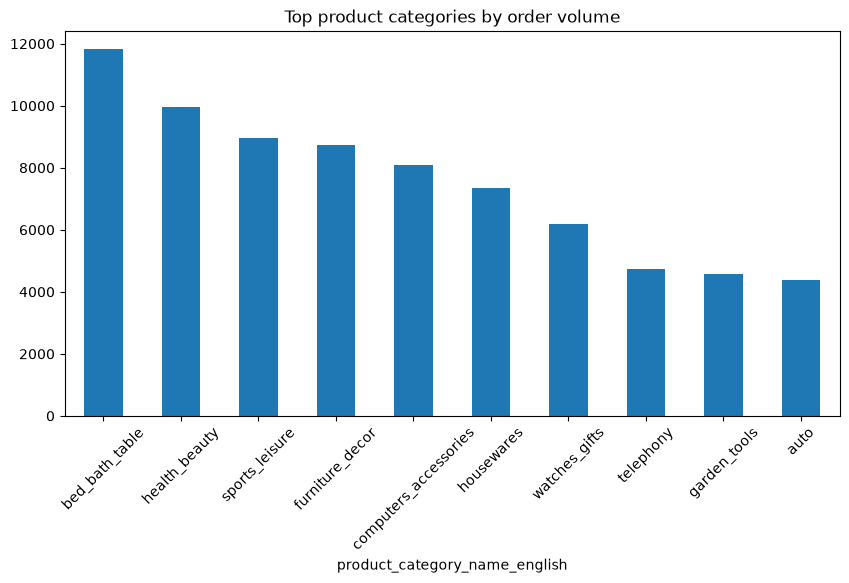

In [18]:
# Top product categories by order volume
category_volume = orders_enriched.groupby("product_category_name_english").size().sort_values(ascending=False).head(10)
print(category_volume)
category_volume.plot(kind="bar", figsize=(10, 5), title="Top product categories by order volume")
plt.xticks(rotation=45)
plt.show()

product_category_name_english
cds_dvds_musicals                        4.642857
fashion_childrens_clothes                4.500000
books_general_interest                   4.438503
books_imported                           4.419355
flowers                                  4.419355
costruction_tools_tools                  4.415842
books_technical                          4.370787
small_appliances_home_oven_and_coffee    4.320513
food_drink                               4.319444
luggage_accessories                      4.295945
Name: review_score, dtype: float64


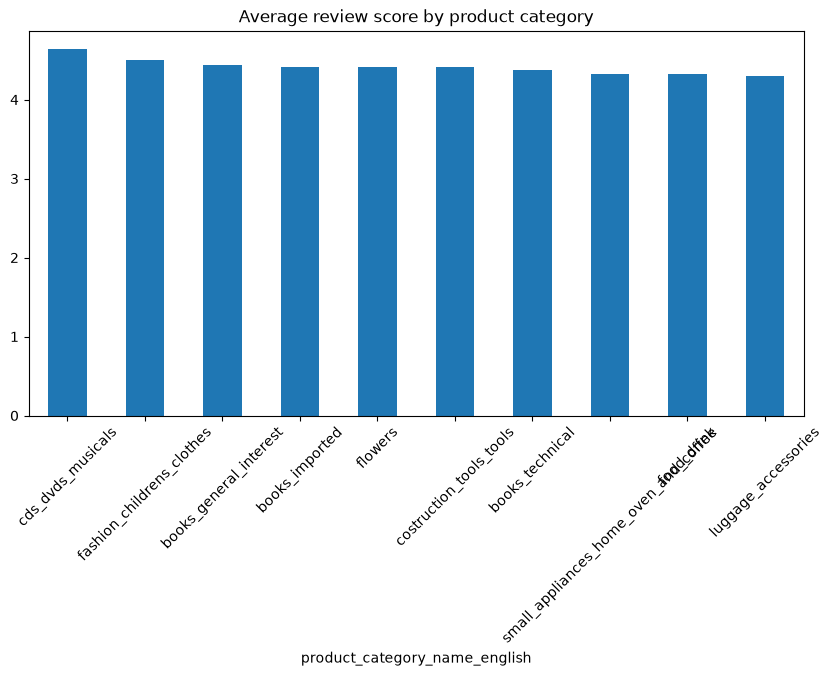

In [19]:
# Average review score by category
category_review = orders_enriched.groupby("product_category_name_english")["review_score"].mean().sort_values(ascending=False).head(10)
print(category_review)
category_review.plot(kind="bar", figsize=(10, 5), title="Average review score by product category")
plt.xticks(rotation=45)
plt.show()

payment_type
credit_card    126.477858
debit_card     108.668681
voucher        105.112152
boleto         104.584146
not_defined           NaN
Name: price, dtype: float64


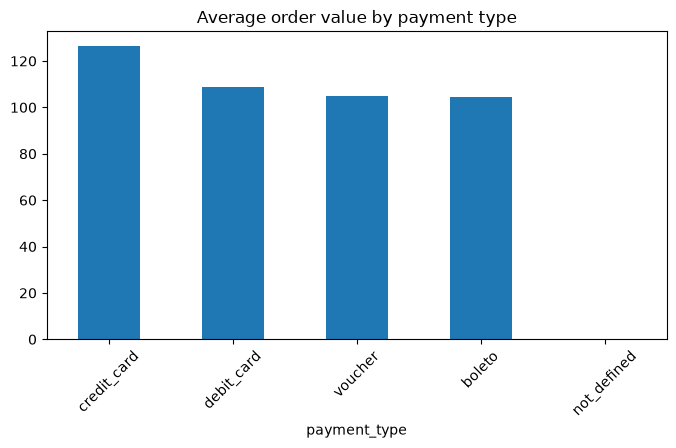

In [15]:
# Average order value by payment type
order_value_by_payment = orders_enriched.groupby("payment_type")["price"].mean().sort_values(ascending=False)
print(order_value_by_payment)
order_value_by_payment.plot(kind="bar", figsize=(8, 4), title="Average order value by payment type")
plt.xticks(rotation=45)
plt.show()

city
sao paulo                18738
rio de janeiro            8252
belo horizonte            3272
brasilia                  2473
curitiba                  1820
campinas                  1750
porto alegre              1662
salvador                  1534
guarulhos                 1412
sao bernardo do campo     1122
Name: count, dtype: int64


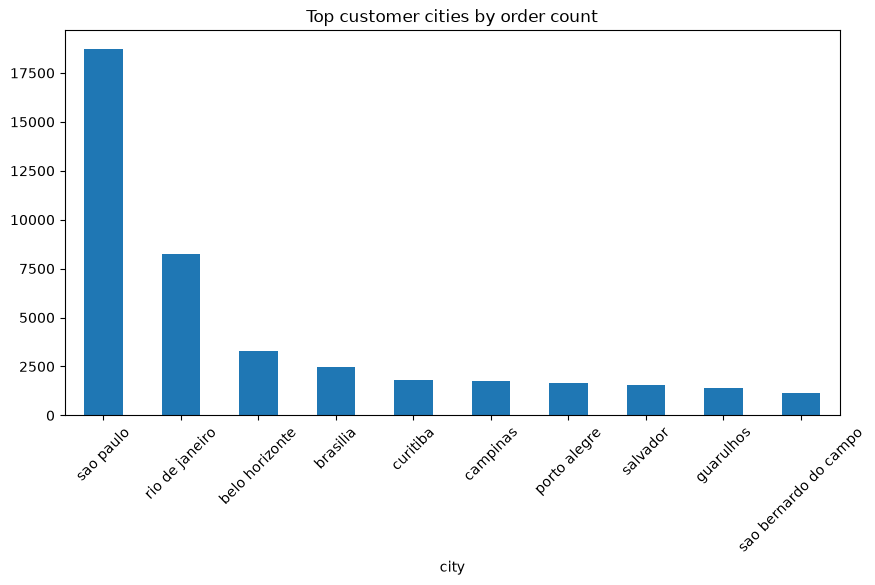

In [16]:
# Top cities by number of orders
city_orders = orders_enriched["city"].value_counts().head(10)
print(city_orders)
city_orders.plot(kind="bar", figsize=(10, 5), title="Top customer cities by order count")
plt.xticks(rotation=45)
plt.show()

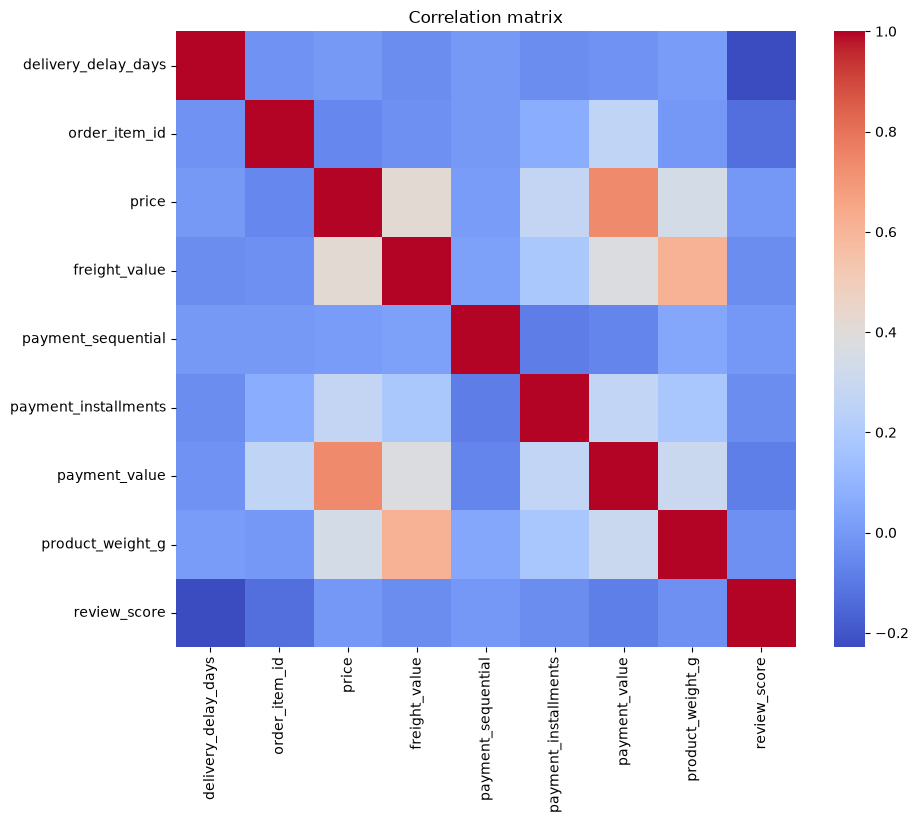

In [17]:
# Correlation heatmap for numeric fields
numeric_cols = orders_enriched.select_dtypes(include=["number"]).columns.tolist()
correlation_matrix = orders_enriched[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=False, cmap="coolwarm")
plt.title("Correlation matrix")
plt.show()

## Key findings

- Review score distribution gives a quick view of product satisfaction.
- Payment type mix highlights customer preference patterns.
- Category-level review averages reveal which product segments need attention.
- City-level order concentration helps identify strong markets.